# Custom SCM Graphs in TiRex-2 Coupling

`CouplingPipeline` can **fix the parent structure** of the linear / nonlinear SCM instead of sampling a random DAG.
Pass a square binary matrix `adjacency` to either entry point:

- `pipe(rng, series, mechanism="linear_scm", adjacency=A)` — couple an existing `(T, Q)` array (`__call__`)
- `pipe.generate(rng, T, mechanism="linear_scm", adjacency=A)` — draw a GP pool of size `Q` from `A.shape`, then couple

Convention: **`adjacency[i, j] = 1` means a directed edge i → j** (i is a parent of j).
Only `linear_scm` / `nonlinear_scm` read this matrix; other mechanisms ignore it.
Lags $\tau_{ij}$ and coefficients $\alpha_{ij}$ are still sampled per present edge.

$$
x_{j,t}
=
\sum_{i \in \mathrm{pa}(j)}
\alpha_{ij}\, z_{i,\, t-\tau_{ij}}
+
\varepsilon_{j,t}
$$

The SCM mixes the **input pool** $z$, not previously computed outputs.
Root nodes (empty parent set) would otherwise become pure noise; the helper below **keeps root channels equal to the input**, so a custom graph can grow new child series on top of existing parents.

This notebook:

1. builds a 4-node DAG on **synthetic** GP series;
2. uses **ETTh1 OT** and **Weather OT** as two real parents and generates two extra children, each depending on **both** real series.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..", "..")))

from s2generator.scm import CouplingPipeline, NonlinearSCM
from s2generator.utils import (
    load_univariate,
    z_score_normalization,
    plot_multivariate_time_series,
    plot_adjacency_matrix,
    plot_graph,
    plot_correlation,
    multivariate_correlation,
)


def channels(series: np.ndarray) -> np.ndarray:
    """(T, Q) -> (Q, T) for the visualisation helpers."""
    return np.asarray(series).T


def pearson(series_tq: np.ndarray) -> np.ndarray:
    return multivariate_correlation(channels(series_tq), measure="pearson")


def print_pearson(series_tq: np.ndarray, names) -> None:
    corr = pearson(series_tq)
    q = corr.shape[0]
    print("Pearson correlation")
    header = "        " + "  ".join(f"{n:>10s}" for n in names)
    print(header)
    for i, name in enumerate(names):
        row = "  ".join(f"{corr[i, j]:10.3f}" for j in range(q))
        print(f"{name:>8s}  {row}")


def keep_roots(
    coupled: np.ndarray, series: np.ndarray, adjacency: np.ndarray
) -> np.ndarray:
    """Replace root-node outputs with the original input series."""
    out = np.asarray(coupled, dtype=float).copy()
    has_parent = np.asarray(adjacency).astype(bool).any(axis=0)
    roots = np.where(~has_parent)[0]
    out[:, roots] = series[:, roots]
    return out


def couple_with_graph(pipe, rng, series, adjacency, mechanism="linear_scm"):
    coupled = pipe(
        rng,
        series,
        mechanism=mechanism,
        adjacency=adjacency,
        apply_postprocessing=False,
    )
    return keep_roots(coupled, series, adjacency)


def show_graph(adjacency: np.ndarray, names) -> None:
    print("node index map:")
    for i, name in enumerate(names):
        print(f"  {i}: {name}")
    fig = plot_graph(adjacency.astype(int), show_matrix=True)
    plt.show()


def show_series(series_tq: np.ndarray, names, title: str) -> None:
    fig = plot_multivariate_time_series(channels(series_tq))
    for i, ax in enumerate(fig.axes[: len(names)]):
        ax.set_ylabel(names[i], fontsize=10)
    fig.axes[0].set_title(title, fontweight="bold", fontsize=12)
    plt.show()
    fig = plot_correlation(channels(series_tq), measure="pearson spearman")
    plt.show()
    print_pearson(series_tq, names)


pipe = CouplingPipeline()
print(pipe)
print("SCM mechanisms:", ["linear_scm", "nonlinear_scm"])

CouplingPipeline
SCM mechanisms: ['linear_scm', 'nonlinear_scm']


## The 4-node graph

Both examples use the same DAG: two **roots** and two **children**.
Every child has **both** roots as parents, so each generated channel is a lagged linear mixture of both inputs.

$$
\begin{aligned}
x_0 &= z_0 \\
x_1 &= z_1 \\
x_2 &= \alpha_{02}\, z_0(t-\tau_{02}) + \alpha_{12}\, z_1(t-\tau_{12}) + \varepsilon_2 \\
x_3 &= \alpha_{03}\, z_0(t-\tau_{03}) + \alpha_{13}\, z_1(t-\tau_{13}) + \varepsilon_3
\end{aligned}
$$

Edges: $0 \to 2$, $1 \to 2$, $0 \to 3$, $1 \to 3$.


In [2]:
Q = 4
adj = np.zeros((Q, Q), dtype=bool)
# both children depend on both parents
adj[0, 2] = adj[1, 2] = True
adj[0, 3] = adj[1, 3] = True
print("adjacency (rows = source, cols = target):")
print(adj.astype(int))

adjacency (rows = source, cols = target):
[[0 0 1 1]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]


## 1. Synthetic GP pool

Draw four independent GP series as the univariate pool (roots in columns 0–1; columns 2–3 are unused placeholders). Then apply `linear_scm` with the custom DAG and restore the two root channels so the figure is “two independent drivers + two generated mixtures”.


synthetic GP pool shape: (256, 4)
node index map:
  0: GP-0 (root)
  1: GP-1 (root)
  2: child-2
  3: child-3


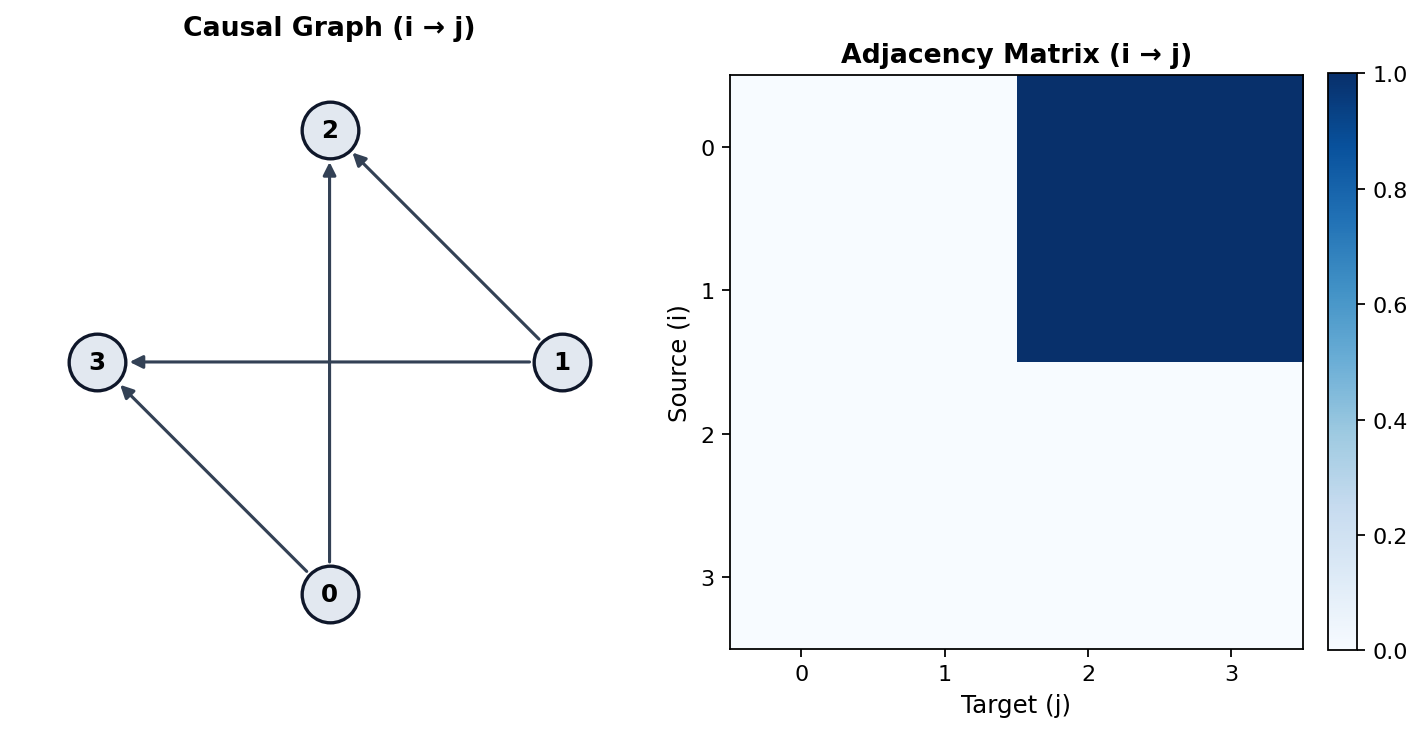

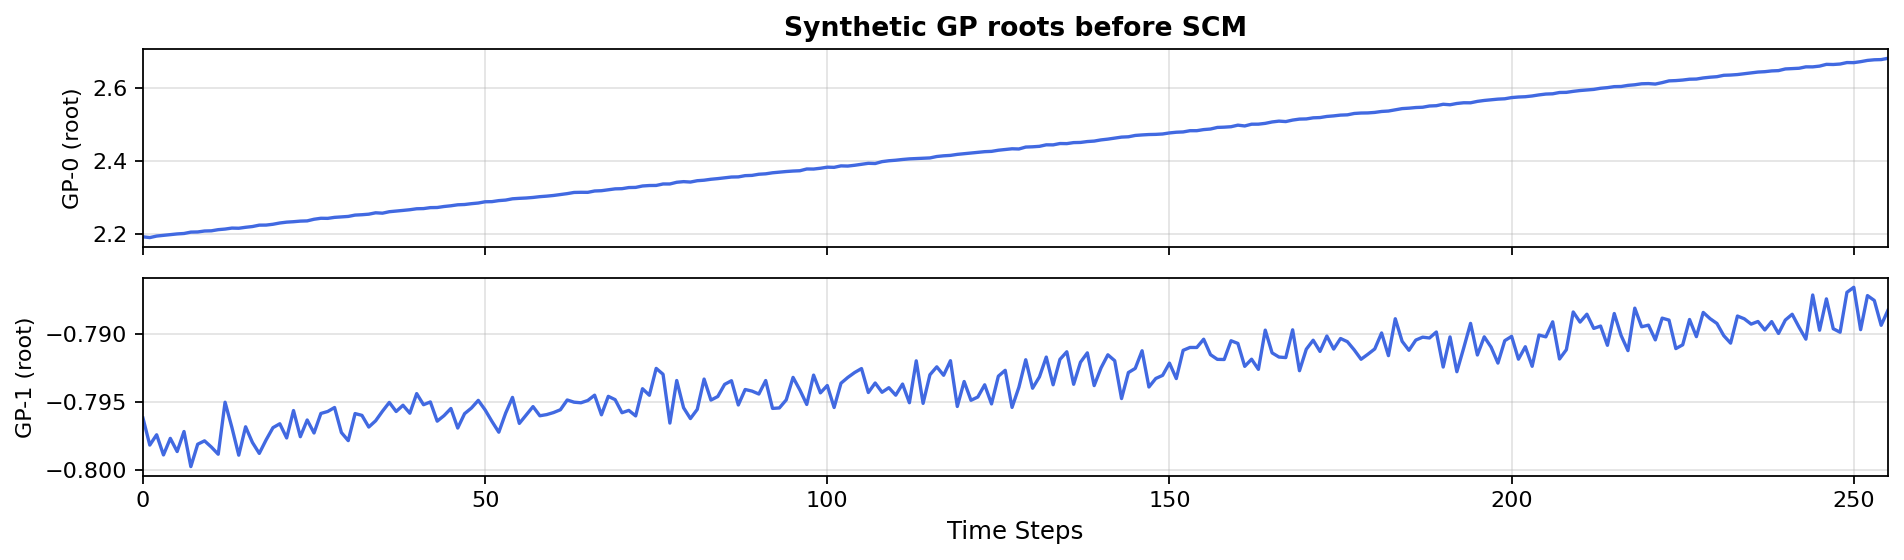

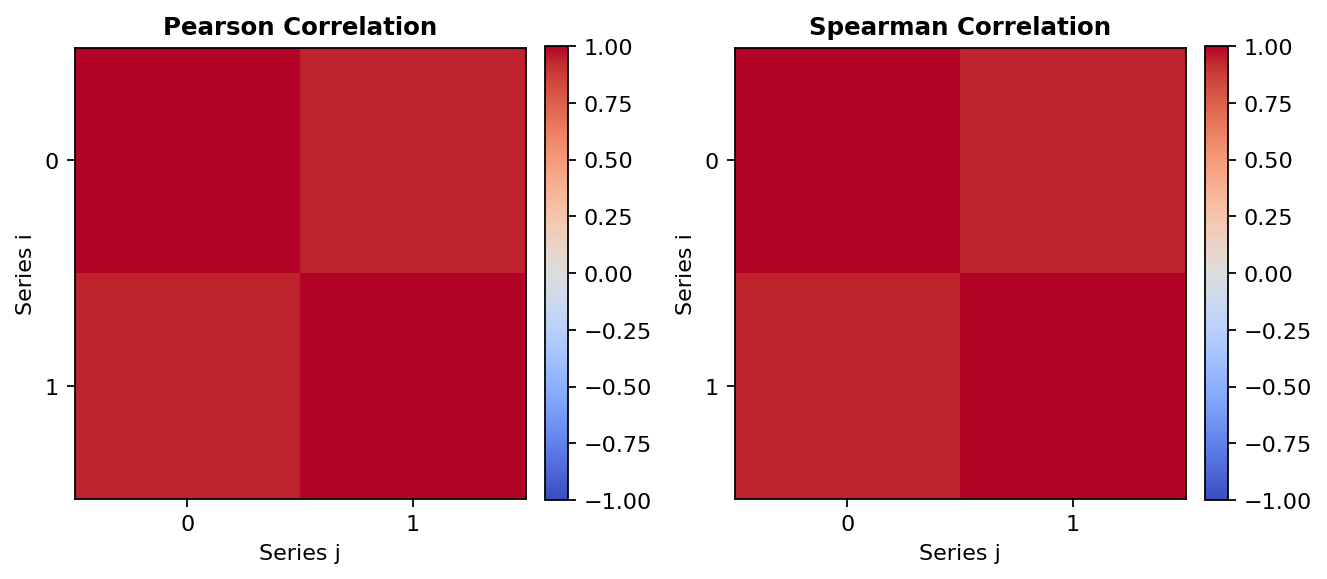

Pearson correlation
        GP-0 (root)  GP-1 (root)
GP-0 (root)       1.000       0.938
GP-1 (root)       0.938       1.000


In [3]:
SYNTH_NAMES = ["GP-0 (root)", "GP-1 (root)", "child-2", "child-3"]
T_synth = 256
rng = np.random.RandomState(0)

# Two independent GP roots; child columns are unused placeholders.
roots = CouplingPipeline._generate_base_series(rng, T_synth, 2)
z_synth = np.column_stack([roots, np.zeros((T_synth, 1)), np.zeros((T_synth, 1))])
print("synthetic GP pool shape:", z_synth.shape)

show_graph(adj, SYNTH_NAMES)
show_series(z_synth[:, :2], SYNTH_NAMES[:2], "Synthetic GP roots before SCM")

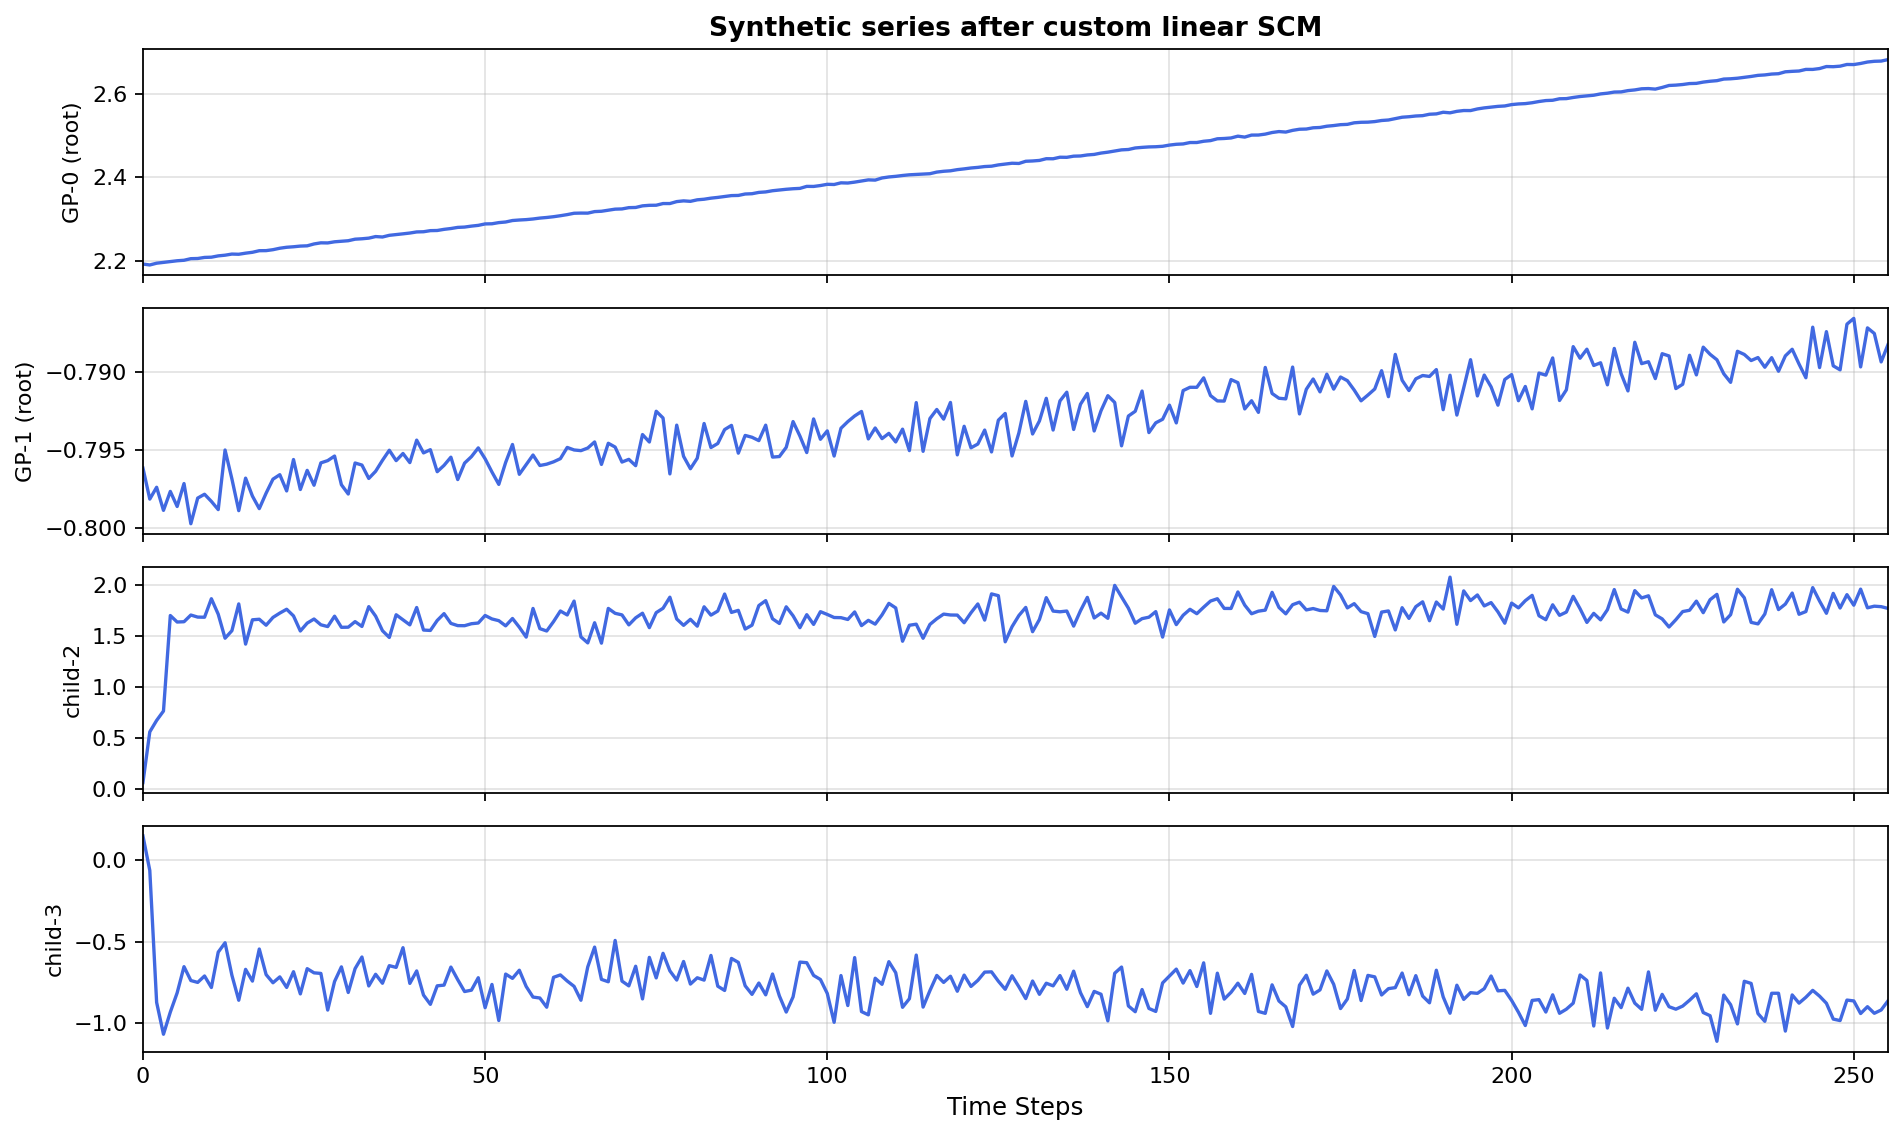

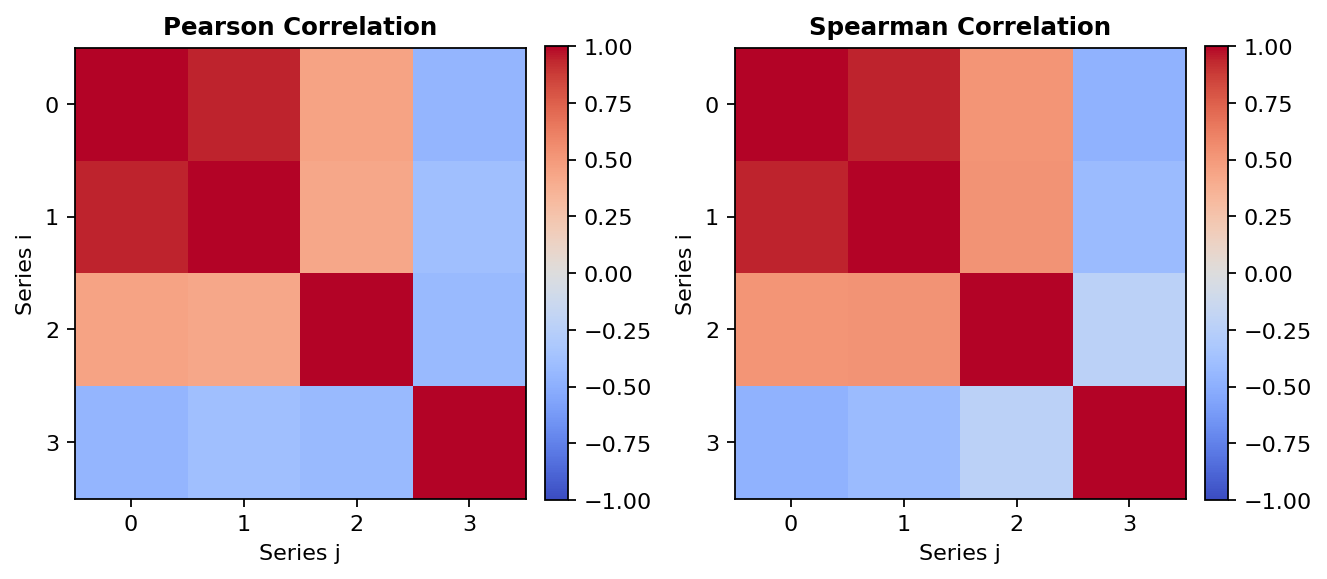

Pearson correlation
        GP-0 (root)  GP-1 (root)     child-2     child-3
GP-0 (root)       1.000       0.938       0.449      -0.460
GP-1 (root)       0.938       1.000       0.429      -0.388
 child-2       0.449       0.429       1.000      -0.425
 child-3      -0.460      -0.388      -0.425       1.000
mean |rho| roots (0,1) before: 0.938
mean |rho| child-2 vs roots after: 0.439
mean |rho| child-3 vs roots after: 0.424


In [4]:
rng = np.random.RandomState(1)
x_synth = couple_with_graph(pipe, rng, z_synth, adj, mechanism="linear_scm")
show_series(x_synth, SYNTH_NAMES, "Synthetic series after custom linear SCM")

corr_before = pearson(z_synth)
corr_after = pearson(x_synth)
print("mean |rho| roots (0,1) before:", f"{abs(corr_before[0, 1]):.3f}")
print(
    "mean |rho| child-2 vs roots after:",
    f"{0.5 * (abs(corr_after[2, 0]) + abs(corr_after[2, 1])):.3f}",
)
print(
    "mean |rho| child-3 vs roots after:",
    f"{0.5 * (abs(corr_after[3, 0]) + abs(corr_after[3, 1])):.3f}",
)

### Decomposition of the synthetic children

Each child is a lagged mixture of the two GP roots.
The cell below overlays the child against both parents (z-scored for display) so the shared shape is visible, and reprints the parent–child Pearson entries.


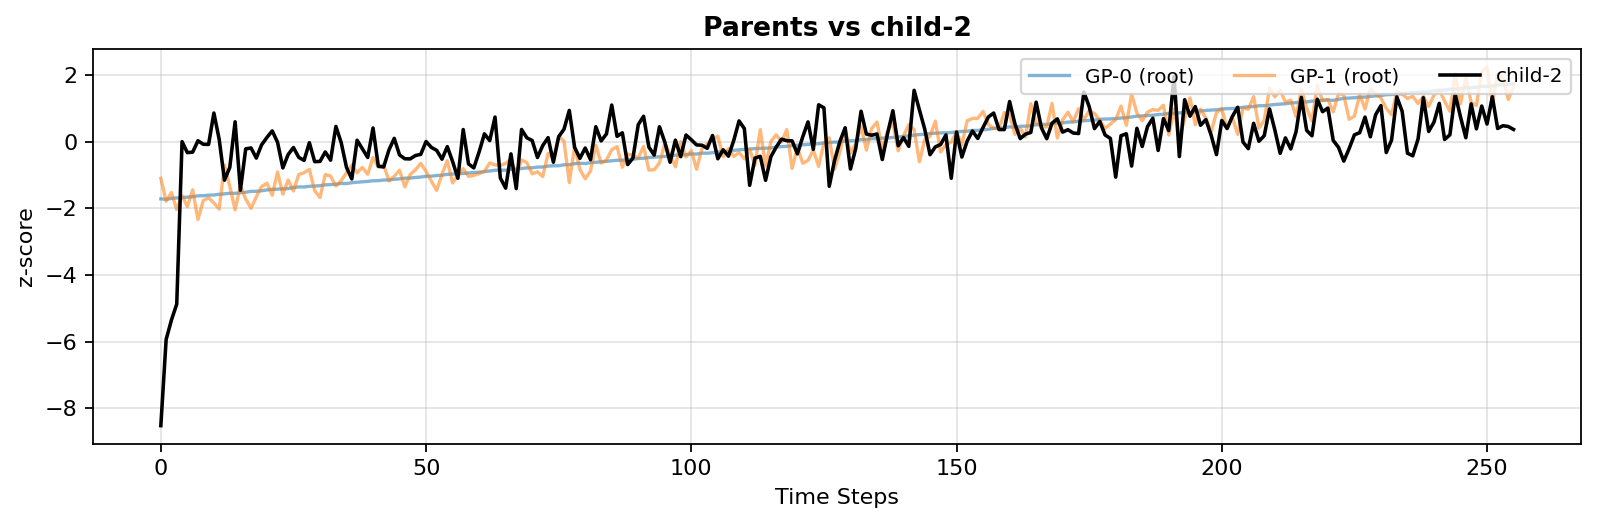

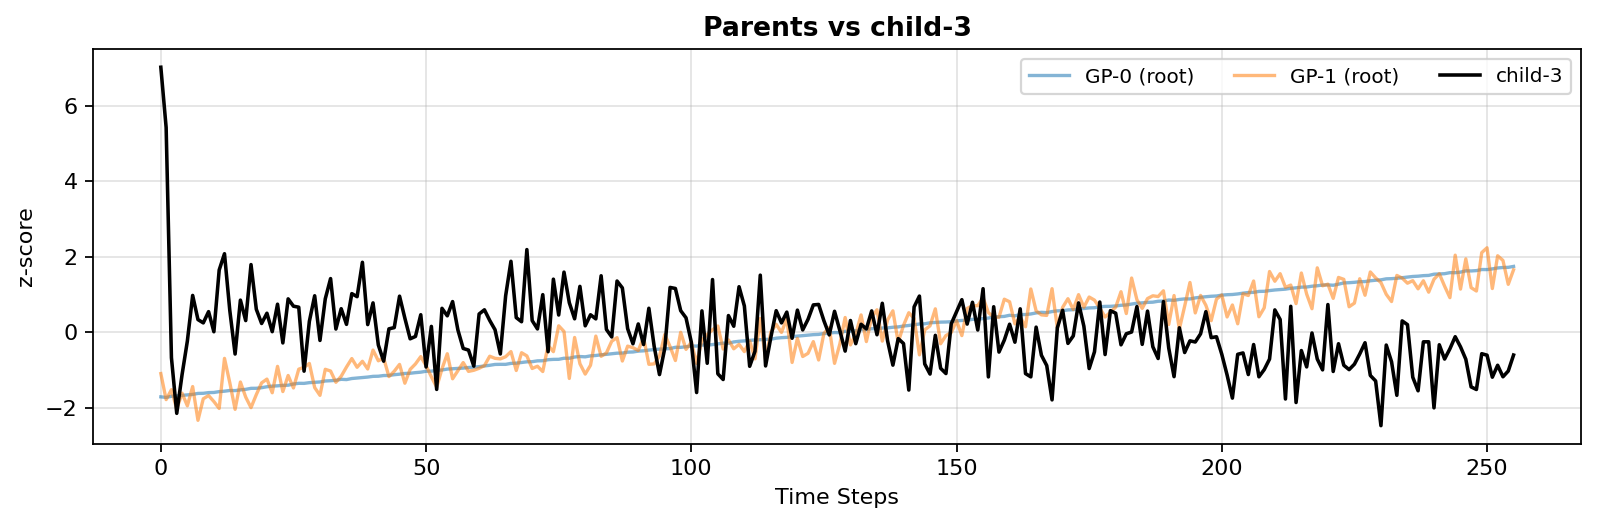

In [5]:
def overlay_parents_child(series_tq, names, child_idx, parent_idx, n_plot=256):
    t = np.arange(n_plot)
    fig, ax = plt.subplots(figsize=(12, 3.2), dpi=160)
    for p in parent_idx:
        y = series_tq[:n_plot, p]
        y = (y - y.mean()) / (y.std() + 1e-8)
        ax.plot(t, y, alpha=0.55, label=names[p])
    y = series_tq[:n_plot, child_idx]
    y = (y - y.mean()) / (y.std() + 1e-8)
    ax.plot(t, y, color="black", lw=1.6, label=names[child_idx])
    ax.set_title(f"Parents vs {names[child_idx]}", fontweight="bold")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("z-score")
    ax.grid(True, alpha=0.35)
    ax.legend(loc="upper right", ncol=3, fontsize=9)
    plt.show()


overlay_parents_child(x_synth, SYNTH_NAMES, child_idx=2, parent_idx=(0, 1))
overlay_parents_child(x_synth, SYNTH_NAMES, child_idx=3, parent_idx=(0, 1))

The same DAG can be applied with `nonlinear_scm` (nonlinear edge maps and an optional gate) on the **same** GP pool, so the only change is the coupling, not the drivers.


nonlinear_scm: nonlinear_scm | custom_adjacency: True


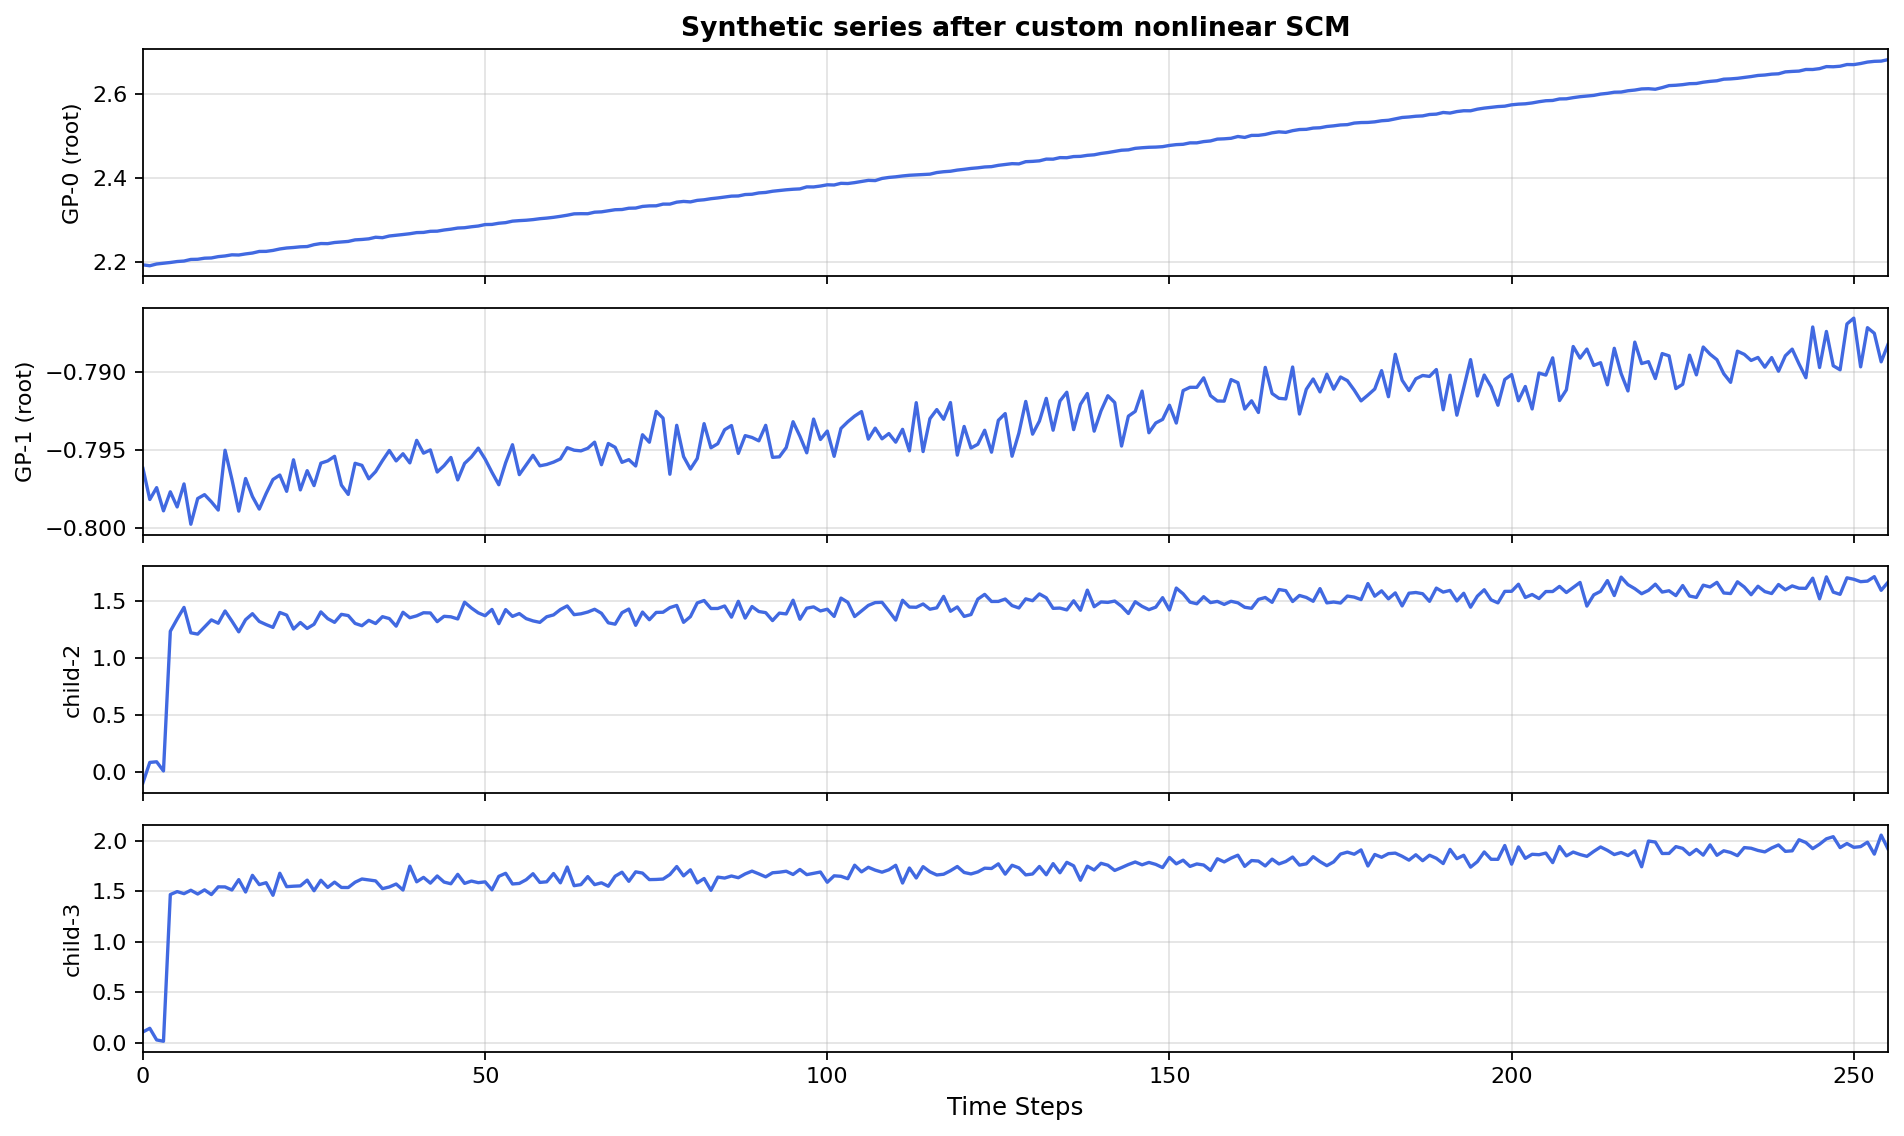

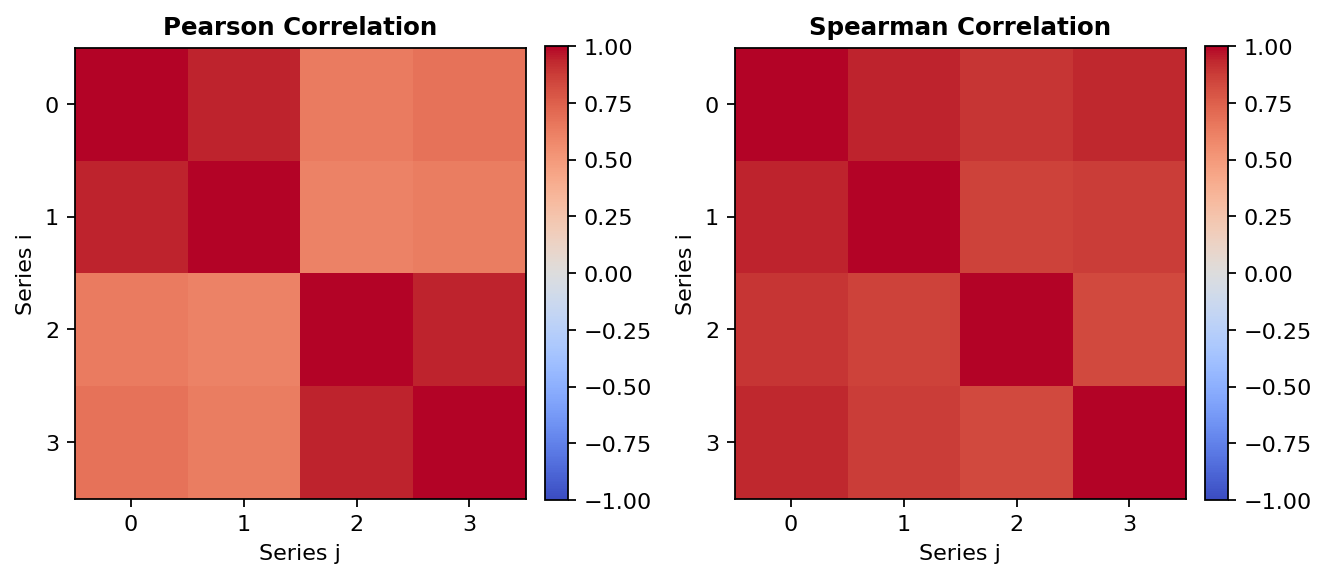

Pearson correlation
        GP-0 (root)  GP-1 (root)     child-2     child-3
GP-0 (root)       1.000       0.938       0.633       0.677
GP-1 (root)       0.938       1.000       0.607       0.630
 child-2       0.633       0.607       1.000       0.944
 child-3       0.677       0.630       0.944       1.000
generate() + linear_scm shape: (256, 4) | custom_adjacency: True


In [6]:
rng = np.random.RandomState(2)
x_nl, meta_nl = pipe(
    rng,
    z_synth,
    mechanism="nonlinear_scm",
    adjacency=adj,
    apply_postprocessing=False,
    return_metadata=True,
)
x_nl = keep_roots(x_nl, z_synth, adj)
print(
    "nonlinear_scm:",
    meta_nl["coupling_mechanism"],
    "| custom_adjacency:",
    meta_nl["custom_adjacency"],
)
show_series(x_nl, SYNTH_NAMES, "Synthetic series after custom nonlinear SCM")

# One-shot API: generate infers Q from adjacency, then applies the SCM.
rng = np.random.RandomState(21)
x_one_shot, meta_os = pipe.generate(
    rng,
    seq_length=T_synth,
    mechanism="linear_scm",
    adjacency=adj,
    apply_postprocessing=False,
    return_metadata=True,
)
print(
    "generate() + linear_scm shape:",
    x_one_shot.shape,
    "| custom_adjacency:",
    meta_os["custom_adjacency"],
)

## 2. Real series: ETTh1 + Weather → 4 channels

Take the bundled **OT** slices (`load_univariate`), z-score them, and place them in columns 0 and 1.
Columns 2 and 3 of the input pool are unused placeholders (zeros): the SCM children read only the parent columns $z_0$ (ETTh1) and $z_1$ (Weather).

After coupling we restore the two real roots, leaving a 4-channel series

$$
(\text{ETTh1},\; \text{Weather},\; \text{child-2},\; \text{child-3})
$$

in which **both generated channels are correlated with both real parents**.


real pool shape: (4096, 4)
node index map:
  0: ETTh1
  1: Weather
  2: child-2
  3: child-3


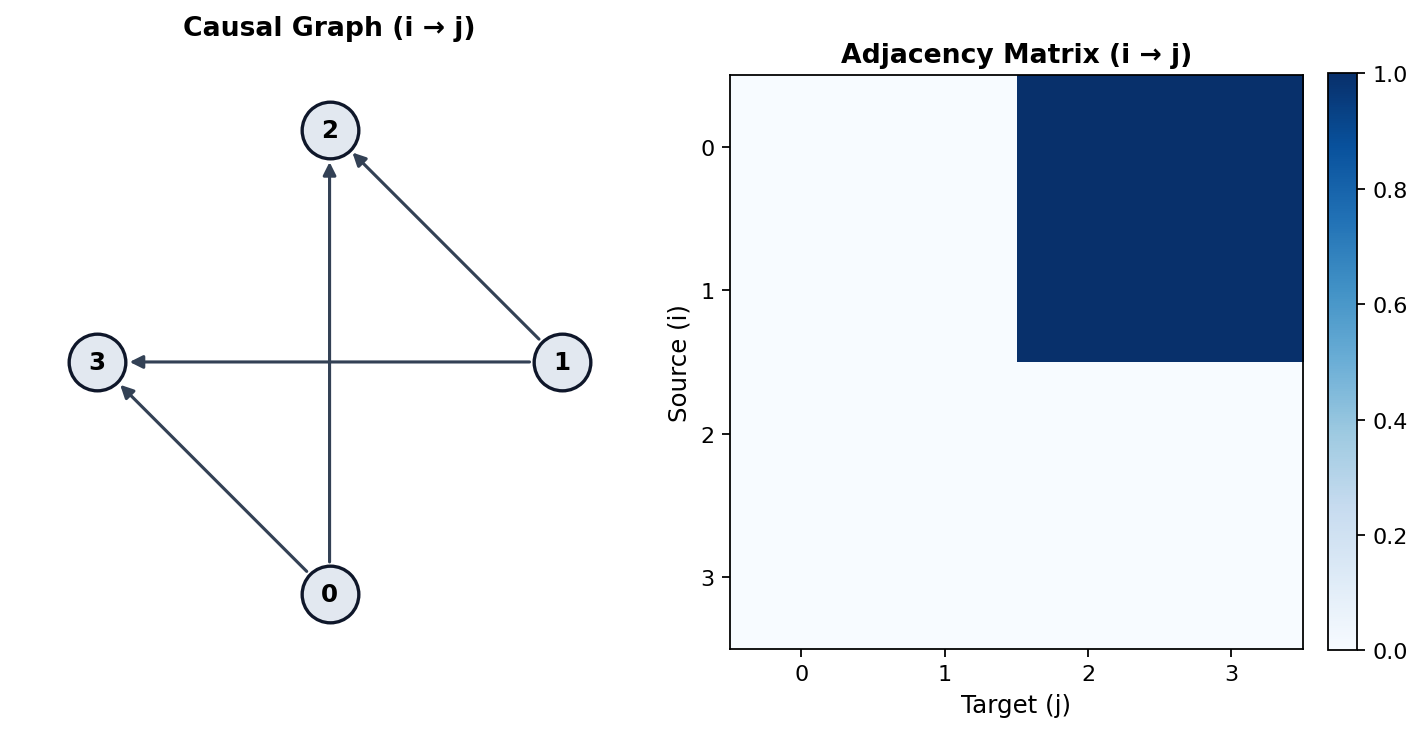

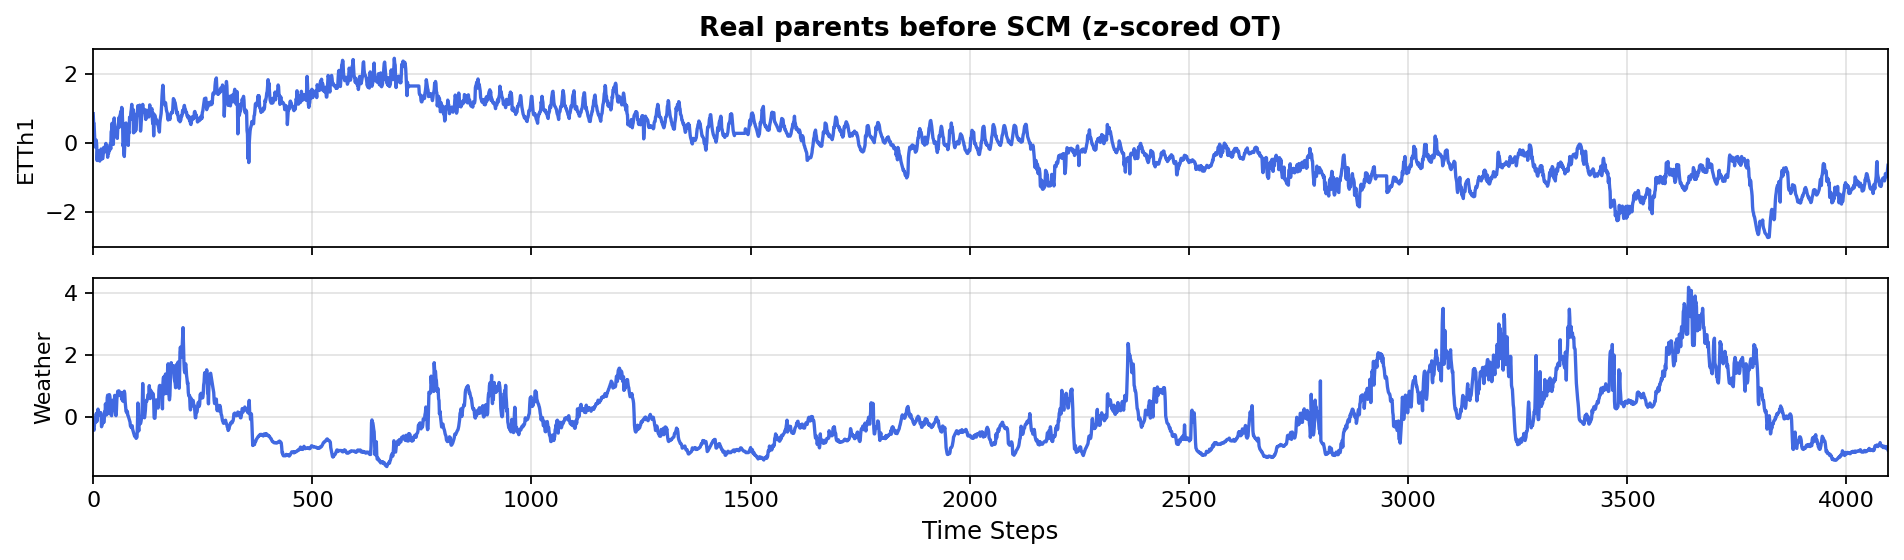

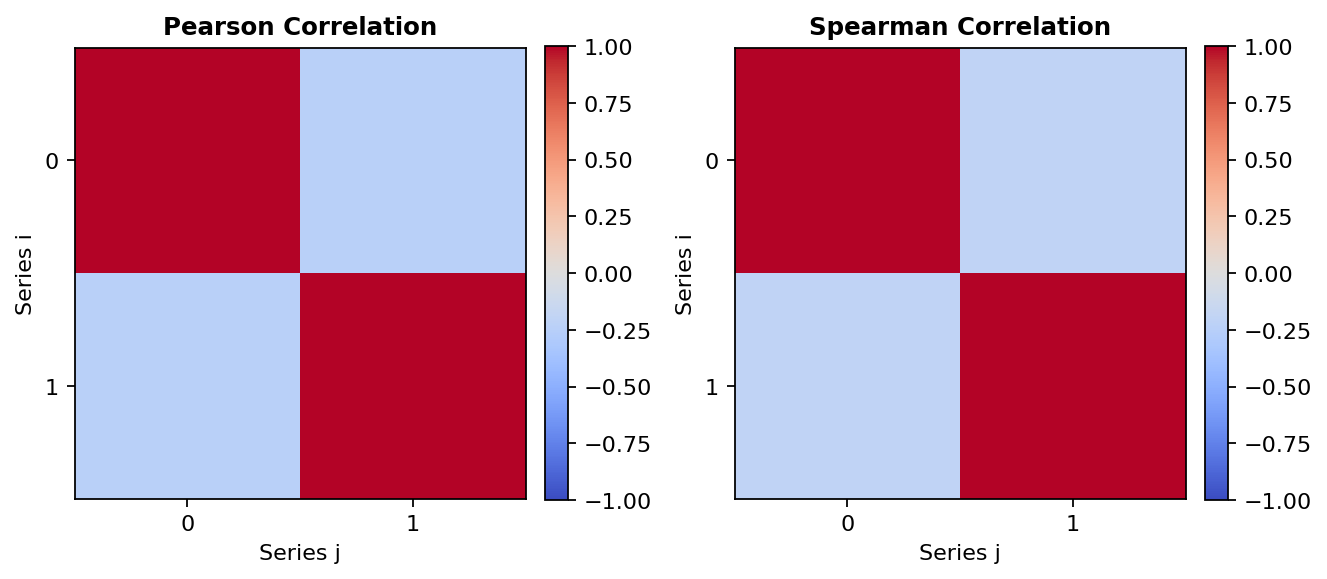

Pearson correlation
             ETTh1     Weather
   ETTh1       1.000      -0.241
 Weather      -0.241       1.000
Pearson(ETTh1, Weather) before coupling: -0.241


In [7]:
REAL_NAMES = ["ETTh1", "Weather", "child-2", "child-3"]

ett = z_score_normalization(load_univariate("ETTh1").reshape(-1, 1)).ravel()
weather = z_score_normalization(load_univariate("weather").reshape(-1, 1)).ravel()
assert ett.shape == weather.shape == (4096,)

z_real = np.column_stack([ett, weather, np.zeros_like(ett), np.zeros_like(ett)])
print("real pool shape:", z_real.shape)

show_graph(adj, REAL_NAMES)
show_series(z_real[:, :2], REAL_NAMES[:2], "Real parents before SCM (z-scored OT)")
print("Pearson(ETTh1, Weather) before coupling:", f"{pearson(z_real[:, :2])[0, 1]:.3f}")

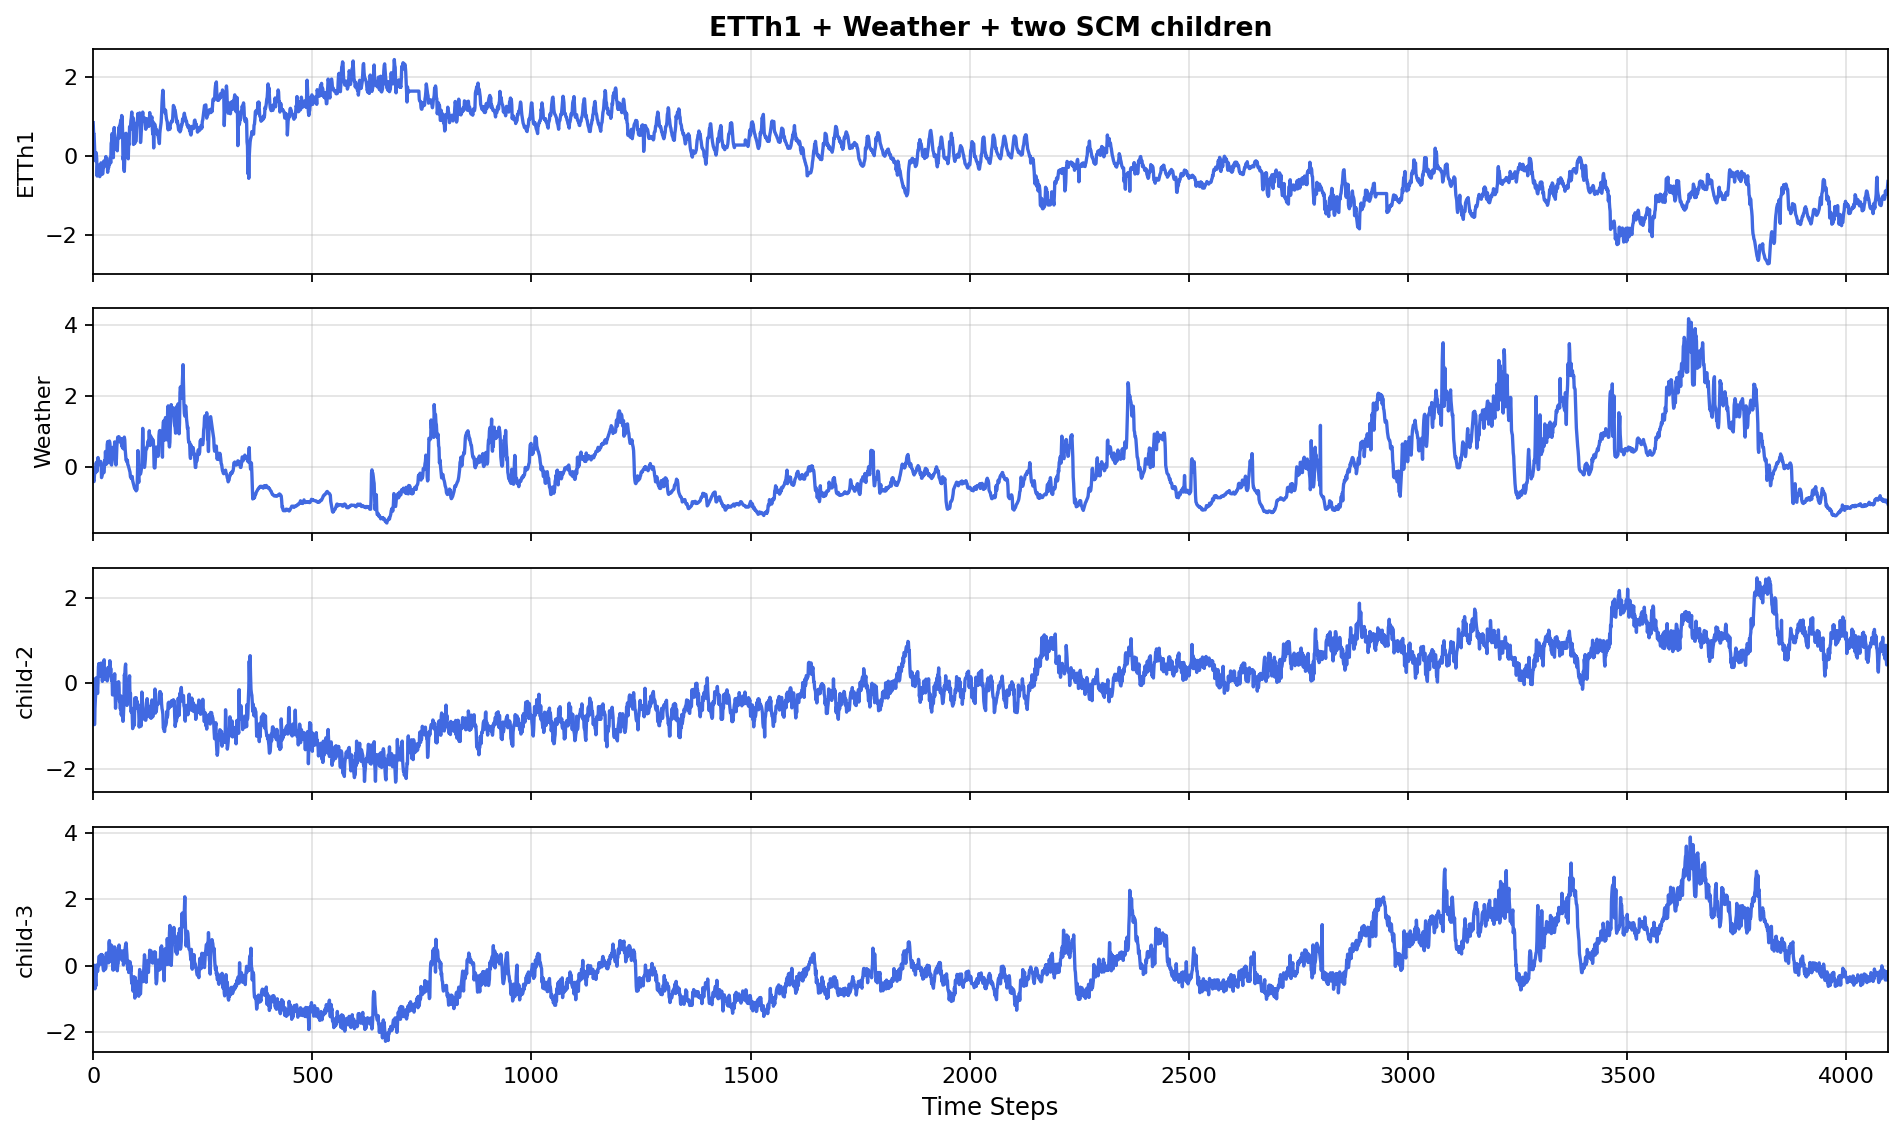

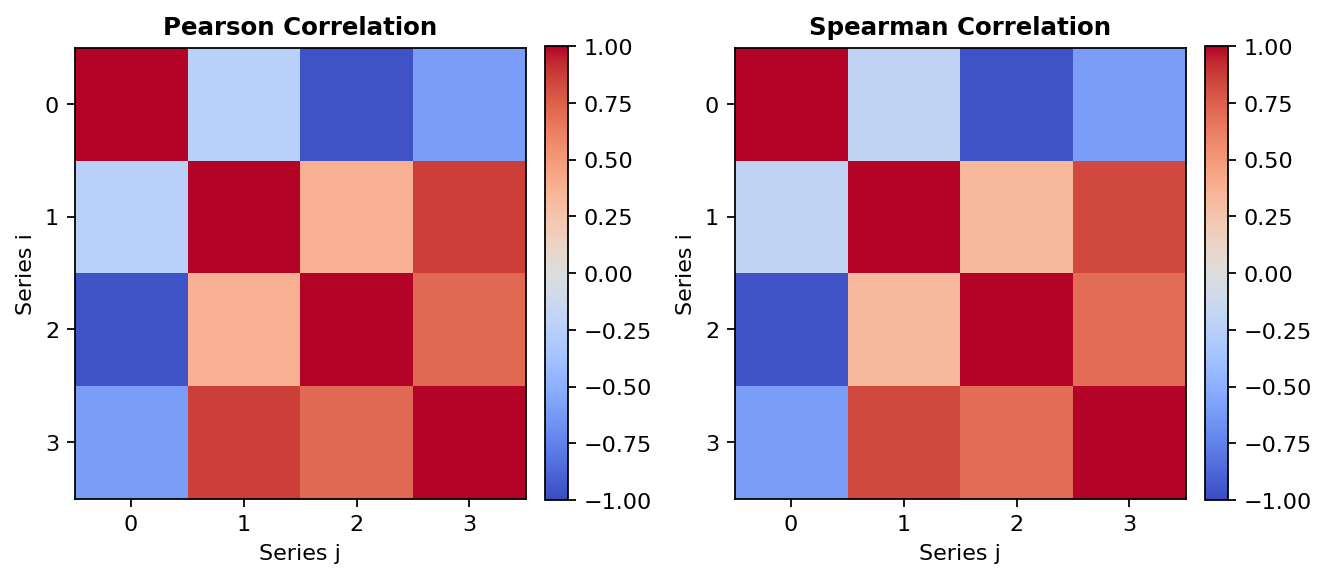

Pearson correlation
             ETTh1     Weather     child-2     child-3
   ETTh1       1.000      -0.241      -0.964      -0.605
 Weather      -0.241       1.000       0.378       0.863
 child-2      -0.964       0.378       1.000       0.713
 child-3      -0.605       0.863       0.713       1.000


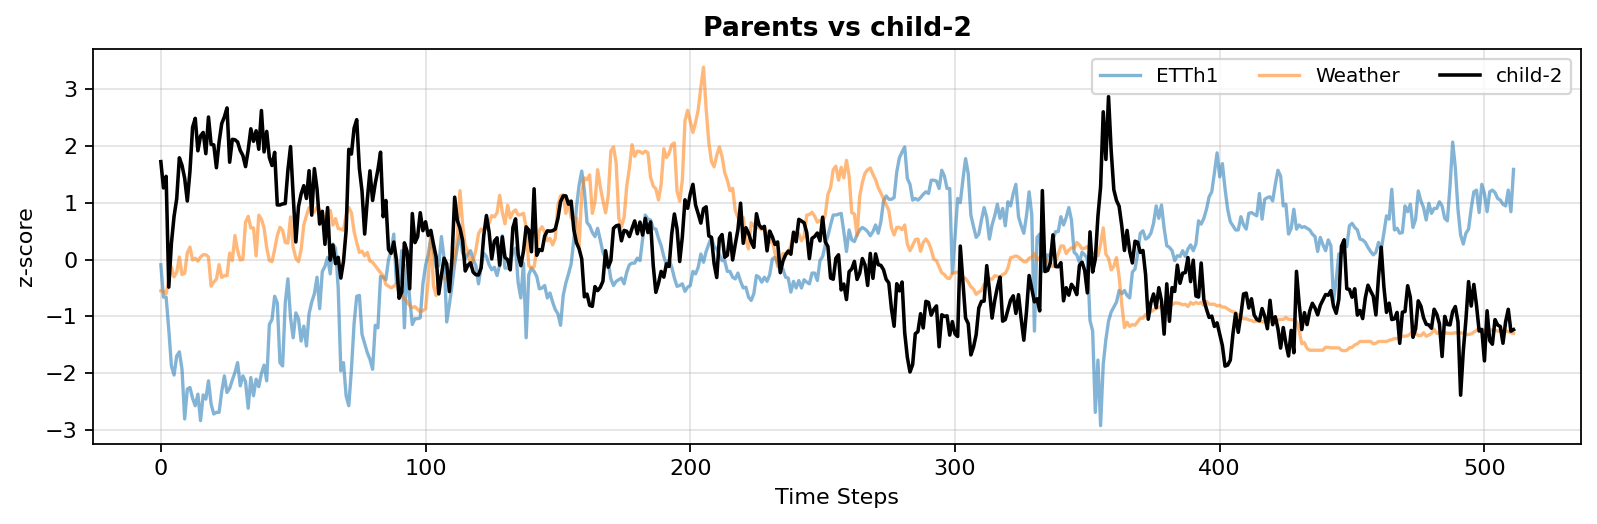

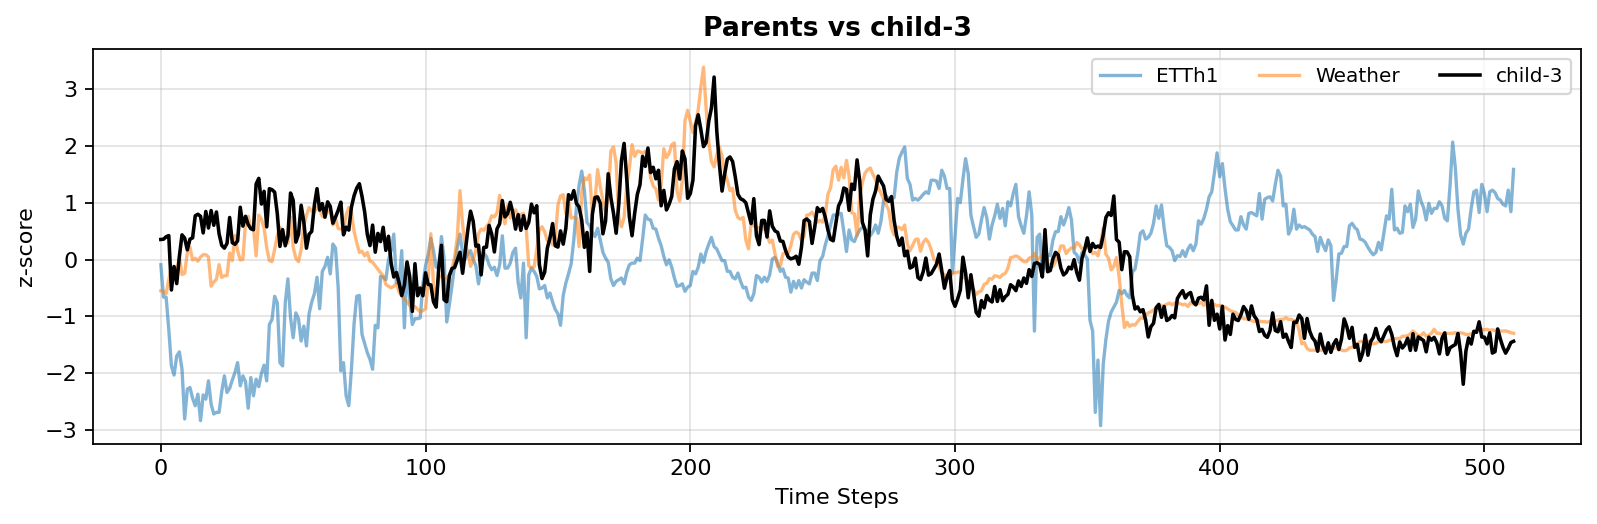

In [8]:
rng = np.random.RandomState(3)
x_real = couple_with_graph(pipe, rng, z_real, adj, mechanism="linear_scm")
assert np.allclose(x_real[:, 0], ett)
assert np.allclose(x_real[:, 1], weather)

show_series(x_real, REAL_NAMES, "ETTh1 + Weather + two SCM children")
overlay_parents_child(x_real, REAL_NAMES, child_idx=2, parent_idx=(0, 1), n_plot=512)
overlay_parents_child(x_real, REAL_NAMES, child_idx=3, parent_idx=(0, 1), n_plot=512)

### Same graph, nonlinear SCM

Repeating the construction with `nonlinear_scm`. The optional multiplicative gate can mute one parent, so this cell uses `use_modulation_gate=False` and additive nonlinear edges $g_{ij}$, keeping both ETTh1 and Weather visible in each child.


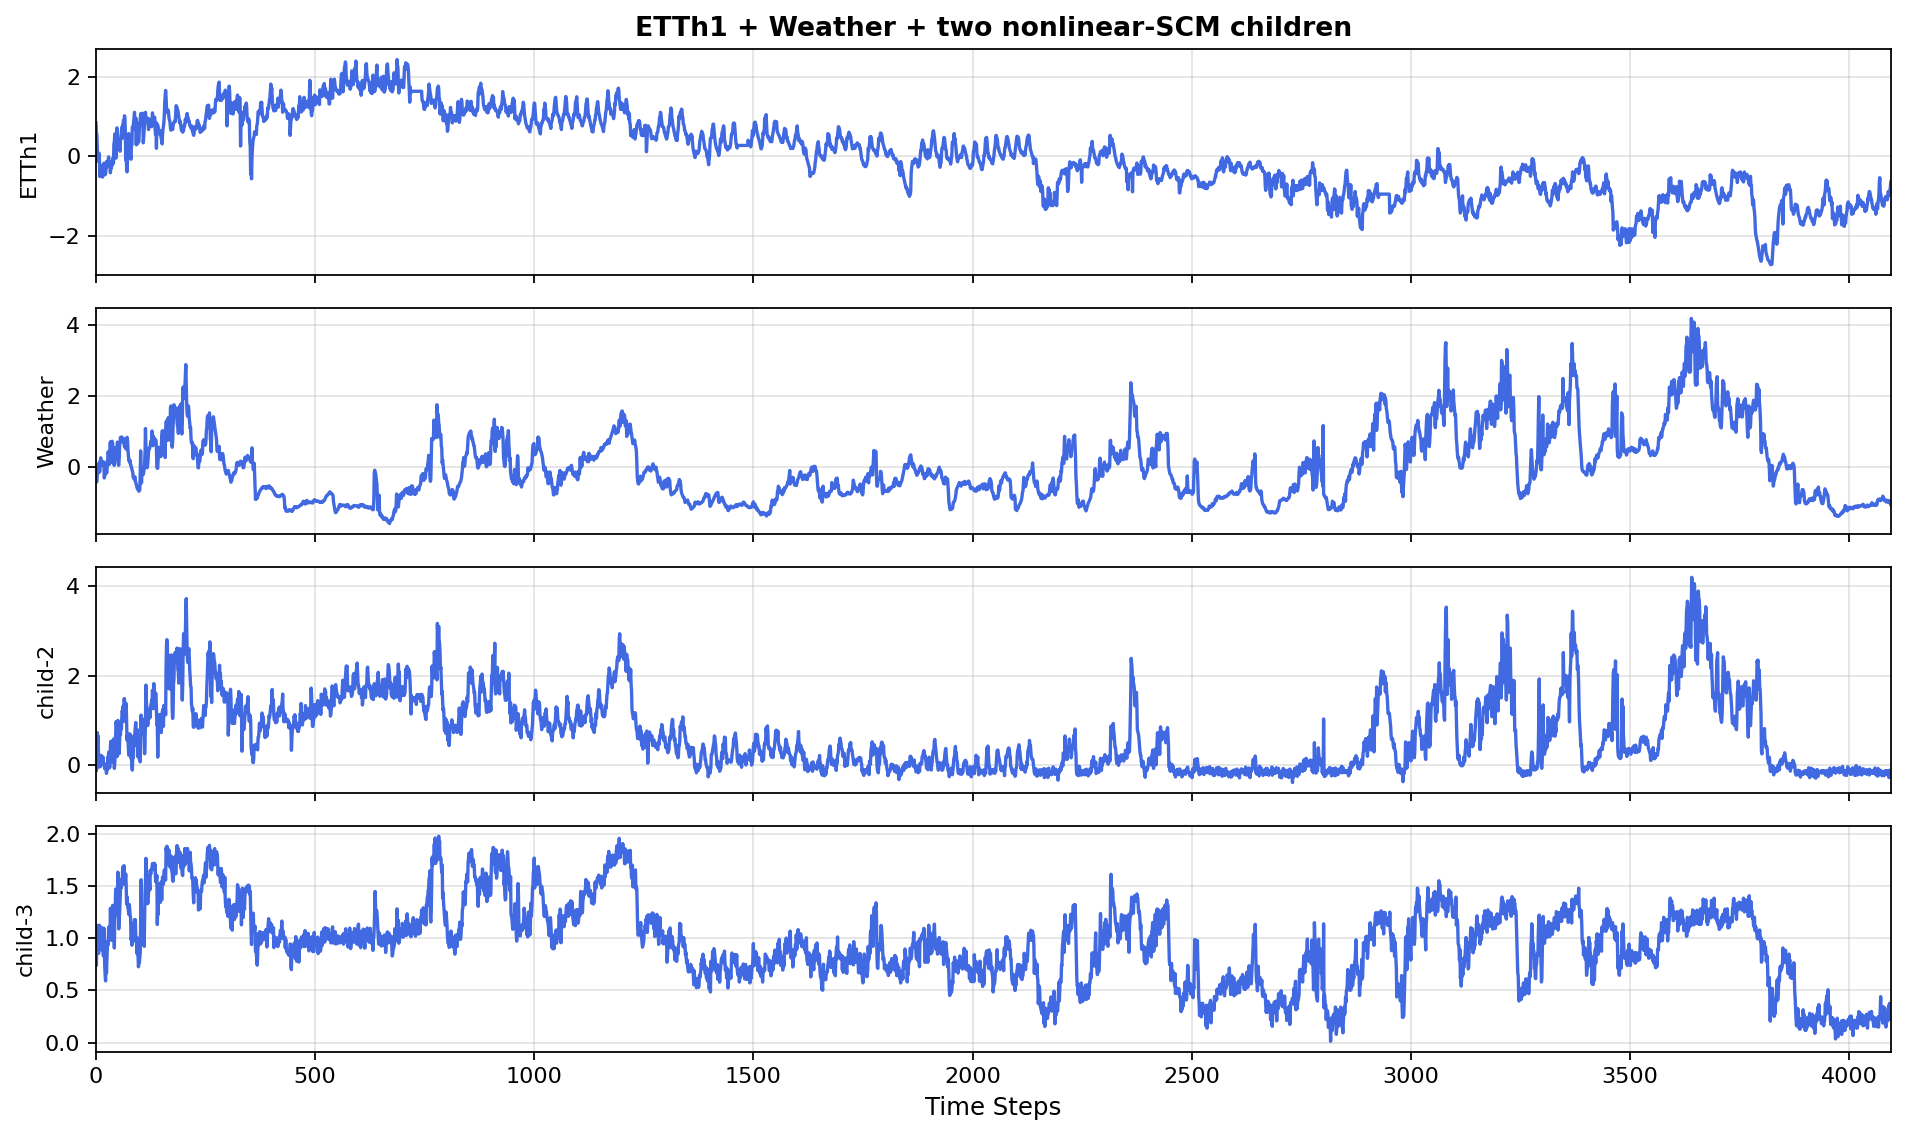

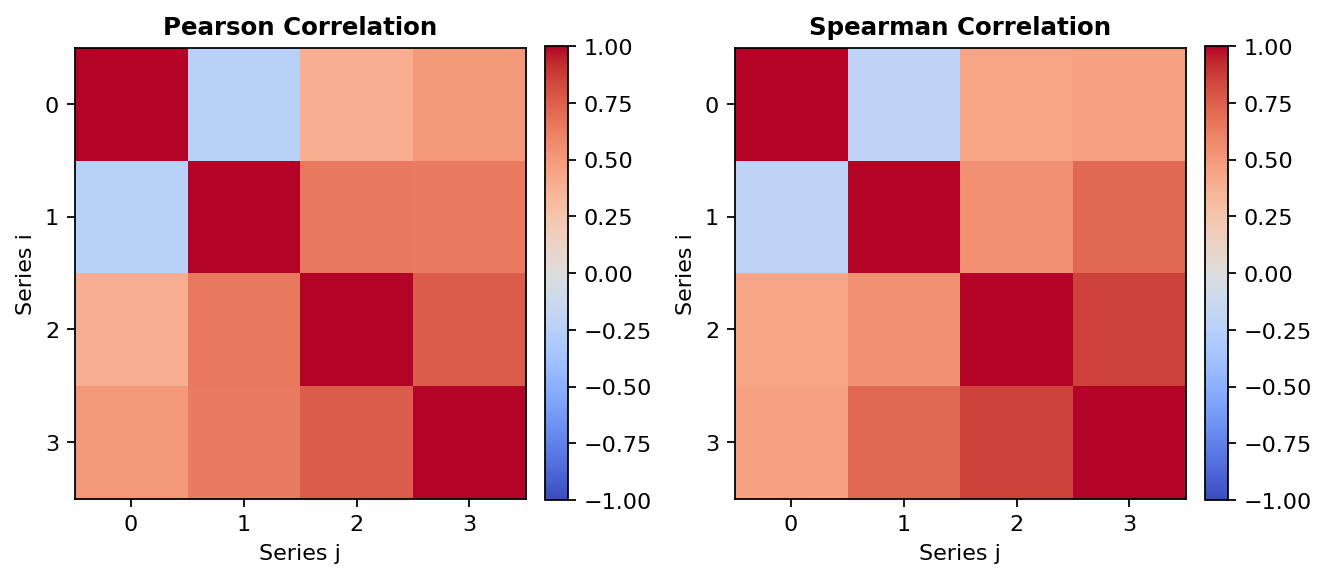

Pearson correlation
             ETTh1     Weather     child-2     child-3
   ETTh1       1.000      -0.241       0.390       0.502
 Weather      -0.241       1.000       0.645       0.635
 child-2       0.390       0.645       1.000       0.765
 child-3       0.502       0.635       0.765       1.000


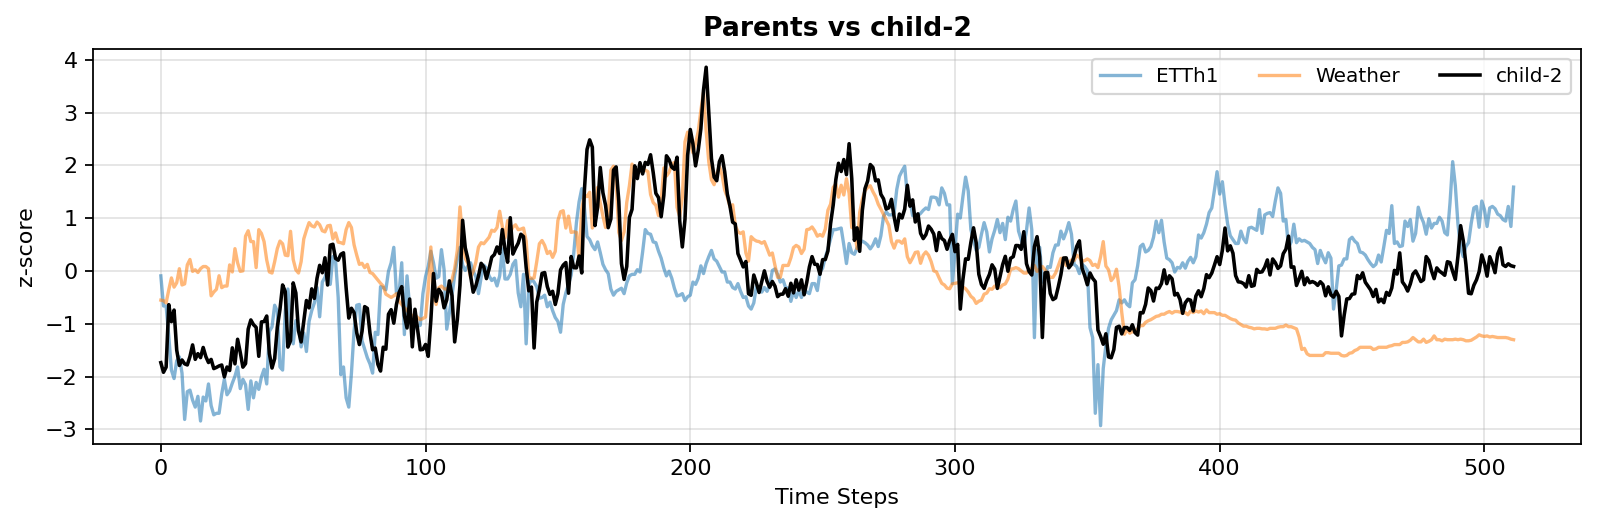

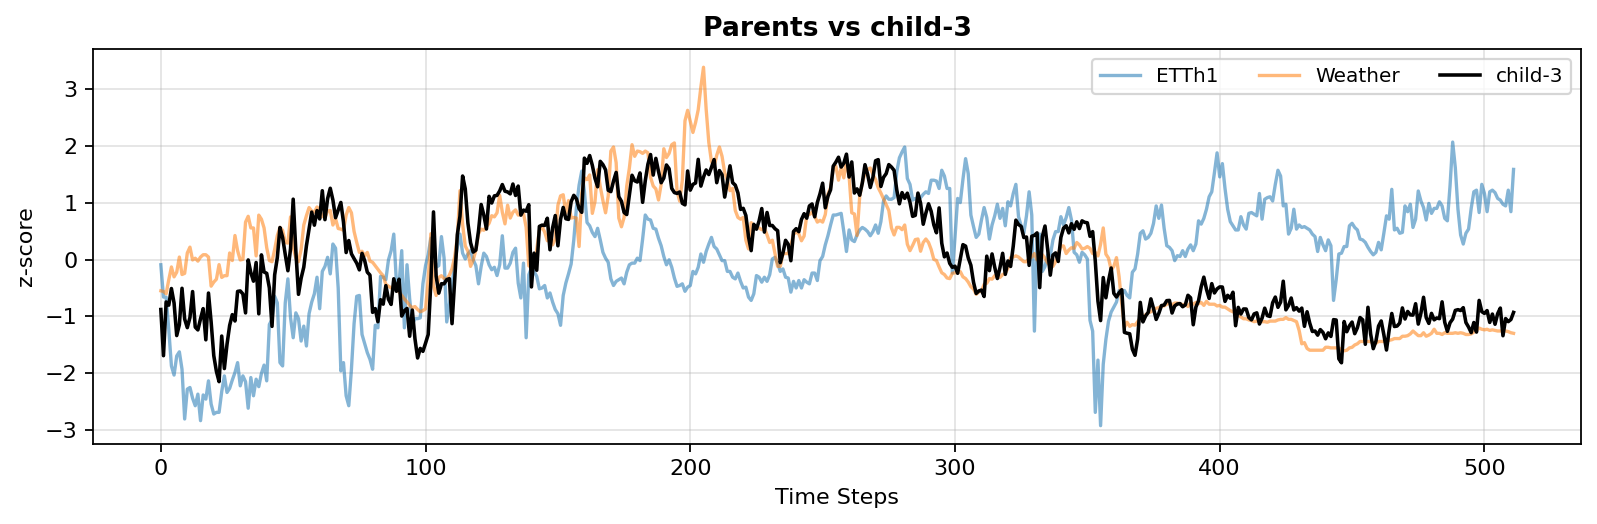

In [9]:
nl_pipe = CouplingPipeline(
    mechanisms={"nonlinear_scm": NonlinearSCM(use_modulation_gate=False)},
    mechanism_probabilities={"nonlinear_scm": 1.0},
)
rng = np.random.RandomState(4)
x_real_nl = couple_with_graph(nl_pipe, rng, z_real, adj, mechanism="nonlinear_scm")
show_series(x_real_nl, REAL_NAMES, "ETTh1 + Weather + two nonlinear-SCM children")
overlay_parents_child(x_real_nl, REAL_NAMES, child_idx=2, parent_idx=(0, 1), n_plot=512)
overlay_parents_child(x_real_nl, REAL_NAMES, child_idx=3, parent_idx=(0, 1), n_plot=512)

## Summary

| Piece | Role |
| --- | --- |
| `adjacency[i, j] = 1` | directed edge **i → j**; only SCM mechanisms use it |
| `pipe(..., adjacency=A)` / `generate(..., adjacency=A)` | fix the parent graph; lags and weights stay random |
| Root restoration | keep real / GP parents in the output; children are the generated channels |
| 4-channel real example | ETTh1 and Weather as roots; two children, each a function of **both** parents |
| `plot_graph` / `plot_adjacency_matrix` | draw the custom DAG |
| `plot_correlation` / `multivariate_correlation` | parent–child dependence after coupling |
